# Predicting 30-day Hospital Readmission for Diabetic Patients
By: Jose Fernando A. Gonzales

# Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ All libraries imported successfully!")
print(f"✓ Random seed set to {RANDOM_STATE}")
print(f"✓ NumPy version: {np.__version__}")
print(f"✓ Pandas version: {pd.__version__}")

✓ All libraries imported successfully!
✓ Random seed set to 42
✓ NumPy version: 2.4.3
✓ Pandas version: 3.0.1


# Importing Dataset

In [2]:
filepath = "../data/raw/diabetic_data.csv"

df = pd.read_csv(filepath)
print(f"✓ Data loaded successfully from {filepath}")

display(df.head())

✓ Data loaded successfully from ../data/raw/diabetic_data.csv


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# Data Preprocessing, EDA & Feature Engineering

## Data Cleaning

In [3]:
# Check for duplicates based on encounter_id
duplicate_count = df.duplicated(subset='encounter_id').sum()
print(f"✓ Number of duplicate entries based on encounter_id: {duplicate_count}")

✓ Number of duplicate entries based on encounter_id: 0


In [4]:
def check_missing_values(dataframe):
    """
        This function checks for missing values in the given DataFrame and returns a summary of the missing values and their percentage.
        
        Parameters:
        dataframe (pd.DataFrame): The input DataFrame to check for missing values.
        
        Returns:
        pd.DataFrame: A DataFrame containing the count and percentage of missing values for each column.
    """

    df_copy = dataframe.copy()

    # Identify columns with missing values represented as '?' since the preview shows that some columns use '?' to indicate missing data
    columns_with_missing = df_copy.columns[df_copy.isin(['?']).any()]
    print(f"✓ Columns with missing values represented as '?': {list(columns_with_missing)}")

    df_copy.replace('?', np.nan, inplace=True)

    missing_values = df_copy.isnull().sum()
    missing_percentage = (missing_values / len(df_copy)) * 100
    missing_df = pd.DataFrame({
        'Missing Values': missing_values,
        'Percentage': missing_percentage
    })
    missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)
    return missing_df

missing_summary = check_missing_values(df)
print("✓ Missing values summary:")
display(missing_summary)

✓ Columns with missing values represented as '?': ['race', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']
✓ Missing values summary:


,Missing Values,Percentage
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


In [5]:
# Replace NaN with 'none' in tests columns
test_columns = ['max_glu_serum', 'A1Cresult']
for col in test_columns:
    df[col] = df[col].fillna('none')
print(f"✓ Missing values in {test_columns} columns replaced with 'none'")

# Replace '?' with 'Unknown' in race column
df['race'] = df['race'].replace('?', 'Unknown')
print("✓ Missing values in 'race' column replaced with 'Unknown'")
display(df['race'].value_counts())

# Group less frequent medical specialties into 'Other' and replace '?' with 'Unknown'
df['medical_specialty'] = df['medical_specialty'].replace(df['medical_specialty'].value_counts()[df['medical_specialty'].value_counts() < 100].index, 'Other')
df['medical_specialty'] = df['medical_specialty'].replace('?', 'Unknown')
print("✓ Medical specialty counts after grouping:")
display(df['medical_specialty'].value_counts())

✓ Missing values in ['max_glu_serum', 'A1Cresult'] columns replaced with 'none'
✓ Missing values in 'race' column replaced with 'Unknown'


race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

✓ Medical specialty counts after grouping:


medical_specialty
Unknown                              49949
InternalMedicine                     14635
Emergency/Trauma                      7565
Family/GeneralPractice                7440
Cardiology                            5352
Surgery-General                       3099
Nephrology                            1613
Orthopedics                           1400
Orthopedics-Reconstructive            1233
Radiologist                           1140
Other                                  925
Pulmonology                            871
Psychiatry                             854
Urology                                685
ObstetricsandGynecology                671
Surgery-Cardiovascular/Thoracic        652
Gastroenterology                       564
Surgery-Vascular                       533
Surgery-Neuro                          468
PhysicalMedicineandRehabilitation      391
Oncology                               348
Pediatrics                             254
Hematology/Oncology                 

In [6]:
# Check for fields with only one unique value (constant fields)
constant_fields = [col for col in df.columns if df[col].nunique() == 1]
print(f"✓ Constant fields (only one unique value): {constant_fields}")

# Identify columns to drop: identifiers, constant fields, and mostly missing fields
identifiers = ['encounter_id', 'patient_nbr']
mostly_missing = ['weight', 'payer_code']

to_drop = identifiers + constant_fields + mostly_missing
print(f"✓ Columns to drop: {to_drop}")

df_cleaned = df.drop(columns=to_drop)
print(f"✓ DataFrame shape after dropping columns: {df_cleaned.shape}")

✓ Constant fields (only one unique value): ['examide', 'citoglipton']
✓ Columns to drop: ['encounter_id', 'patient_nbr', 'examide', 'citoglipton', 'weight', 'payer_code']
✓ DataFrame shape after dropping columns: (101766, 44)


I decided to drop the fields above due to the following reasons:
- encounter_id and patient_nbr: They are identifiers and will only add noise to the model.
- weight: About 96.86% missing. It is too sparse to be useful.
- payer_code: About 39.56% missing. This can just add noise and will most likely not add any useful information. 
- examide and citoglipton: They are constant columns with only one value. They have no predictive value for this dataset.

I chose to keep the other fields for the following reasons:
- max_glue_serum and A1Cresult: Replaced missing values with 'none' string as the tests not being taken might be meaningful in itself.
- rase: Missing ness is low enough to keep.
- medical_specialty: It has high missingness at 49.08%, but it might still offer insights. I also decided to group rarer specialties into 'Other'.

In [7]:
# Correct the data types of id columns to 'category' since they are categorical in nature
df_cleaned['admission_type_id'] = df_cleaned['admission_type_id'].astype('category')
df_cleaned['discharge_disposition_id'] = df_cleaned['discharge_disposition_id'].astype('category')
df_cleaned['admission_source_id'] = df_cleaned['admission_source_id'].astype('category')
print("✓ Data types after correction:")
display(df_cleaned.dtypes)

✓ Data types after correction:


race                             str
gender                           str
age                              str
admission_type_id           category
discharge_disposition_id    category
admission_source_id         category
time_in_hospital               int64
medical_specialty                str
num_lab_procedures             int64
num_procedures                 int64
num_medications                int64
number_outpatient              int64
number_emergency               int64
number_inpatient               int64
diag_1                           str
diag_2                           str
diag_3                           str
number_diagnoses               int64
max_glu_serum                    str
A1Cresult                        str
metformin                        str
repaglinide                      str
nateglinide                      str
chlorpropamide                   str
glimepiride                      str
acetohexamide                    str
glipizide                        str
g

In [8]:
target = 'readmitted'
print(f"✓ Target variable identified: {target}")

numerical_columns = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
print(f"✓ Numerical columns identified: {list(numerical_columns)}")

categorical_columns = df_cleaned.select_dtypes(include=['object', 'category', 'str']).columns
categorical_columns = categorical_columns[categorical_columns != target]
print(f"✓ Categorical columns identified: {list(categorical_columns)}")

✓ Target variable identified: readmitted
✓ Numerical columns identified: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
✓ Categorical columns identified: ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [9]:
def check_for_outliers(dataframe, columns):
    """
        This function checks for outliers in the specified columns of the given DataFrame using the IQR method and returns a summary of the outliers.
        
        Parameters:
        dataframe (pd.DataFrame): The input DataFrame to check for outliers.
        columns (list): A list of column names to check for outliers.
        
        Returns:
        pd.DataFrame: A DataFrame containing the count and percentage of outliers in the specified columns.
    """

    outlier_summary = []
    for col in columns:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = dataframe[(dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)]
        outlier_count = outliers.shape[0]
        outlier_percentage = (outlier_count / len(dataframe)) * 100
        outlier_summary.append({
            'Column': col,
            'Outlier Count': outlier_count,
            'Outlier Percentage': outlier_percentage
        })
    return pd.DataFrame(outlier_summary)

outlier_summary = check_for_outliers(df_cleaned, numerical_columns)
print("✓ Outlier summary for numerical columns:")
display(outlier_summary)

print("✓ Summary statistics:")
display(df_cleaned.describe())

✓ Outlier summary for numerical columns:


,Column,Outlier Count,Outlier Percentage
0,time_in_hospital,2252,2.212920
1,num_lab_procedures,143,0.140518
2,num_procedures,4954,4.868031
3,num_medications,2557,2.512627
4,number_outpatient,16739,16.448519
5,number_emergency,11383,11.185465
6,number_inpatient,7049,6.926675
7,number_diagnoses,281,0.276124


✓ Summary statistics:


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


Outliers were identified in numeric variables using the IQR method. However, because the dataset contains healthcare utilization counts, many statistically extreme values were interpreted as plausible real-world observations rather than data errors. In particular, variables such as prior outpatient, emergency, and inpatient visits were highly right-skewed but clinically meaningful, so they were retained for modeling rather than removed.

In [10]:
filepath_cleaned = "../data/processed/diabetic_data_cleaned.csv"
df_cleaned.to_csv(filepath_cleaned, index=False)
print(f"✓ Cleaned DataFrame saved to {filepath_cleaned}")

✓ Cleaned DataFrame saved to ../data/processed/diabetic_data_cleaned.csv


## Exploratory Data Analysis (EDA)

### Univariate analysis of the target

✓ Univariate Analysis for Categorical Columns:


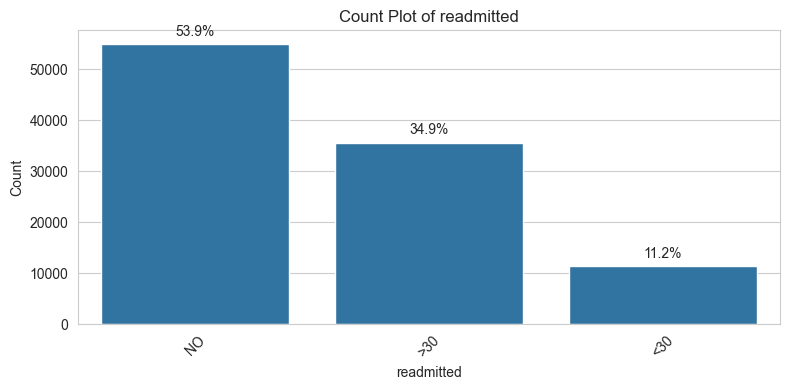

In [11]:
def display_univariate_analysis(dataframe, numerical_cols=None, categorical_cols=None, bins=30):
    """
        This function displays univariate analysis for numerical and categorical columns in the given DataFrame.
        
        Parameters:
        dataframe (pd.DataFrame): The input DataFrame to analyze.
        numerical_cols (list): A list of numerical column names to analyze.
        categorical_cols (list): A list of categorical column names to analyze.
    """

    def annotate_percentages(ax, total_count):
        for patch in ax.patches:
            height = patch.get_height()
            if height == 0:
                continue
            percentage = (height / total_count) * 100
            ax.annotate(
                f'{percentage:.1f}%',
                (patch.get_x() + patch.get_width() / 2, height),
                ha='center',
                va='bottom',
                xytext=(0, 4),
                textcoords='offset points'
            )

    if numerical_cols is None and categorical_cols is None:
        raise ValueError("At least one of numerical_cols or categorical_cols must be provided.")

    if numerical_cols is not None:
        print("✓ Univariate Analysis for Numerical Columns:")
        for col in numerical_cols:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))

            # Histogram
            sns.histplot(data=dataframe, x=col, bins=bins, kde=True, ax=axes[0])
            axes[0].set_title(f'Distribution of {col}')
            axes[0].set_xlabel(col)

            # Boxplot
            sns.boxplot(data=dataframe, x=col, ax=axes[1])
            axes[1].set_title(f'Boxplot of {col}')
            axes[1].set_xlabel(col)

            plt.tight_layout()
            plt.show()

        print("Summary statistics for numerical columns:")
        display(dataframe[numerical_cols].describe())

    if categorical_cols is not None:
        print("✓ Univariate Analysis for Categorical Columns:")
        for col in categorical_cols:
            non_null = dataframe[col].dropna()
            total = len(non_null)

            # If too many categories, show table instead
            if dataframe[col].nunique(dropna=True) > 10:
                print(f"✓ Showing value counts for {col} (more than 10 unique values):")
                counts = dataframe[col].value_counts(dropna=False)
                percentages = dataframe[col].value_counts(dropna=False, normalize=True) * 100

                summary_df = pd.DataFrame({
                    'count': counts,
                    'percentage (%)': percentages.round(1)
                })

                display(summary_df)
                continue

            plt.figure(figsize=(8, 4))
            ax = sns.countplot(data=dataframe, x=col, order=dataframe[col].value_counts().index)
            plt.title(f'Count Plot of {col}')
            plt.xlabel(col)
            plt.ylabel("Count")

            annotate_percentages(ax, total)

            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

display_univariate_analysis(df_cleaned, None, [target])

For the interest of this project, we will convert readmitted into:

- 1 = readmitted within 30 days -> "<30"
- 0 = not readmitted within 30 days -> "NO" and ">30"

✓ Target variable 'readmitted' value counts after encoding:


readmitted
0    90409
1    11357
Name: count, dtype: int64

✓ Univariate Analysis for Categorical Columns:


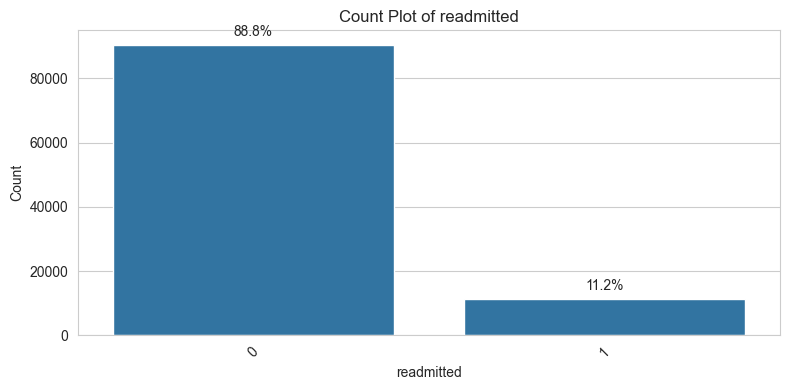

In [12]:
df_cleaned[target] = df_cleaned[target].replace({'<30': 1, '>30': 0, 'NO': 0})
print(f"✓ Target variable '{target}' value counts after encoding:")
display(df_cleaned[target].value_counts())

display_univariate_analysis(df_cleaned, None, [target])

We can observe some imbalance in the dataset for the target variable.

### Univariate analysis of the numerical columns

Given that we only have 8 numerical columns, we can do univariate analysis for all of them.

✓ Univariate Analysis for Numerical Columns:


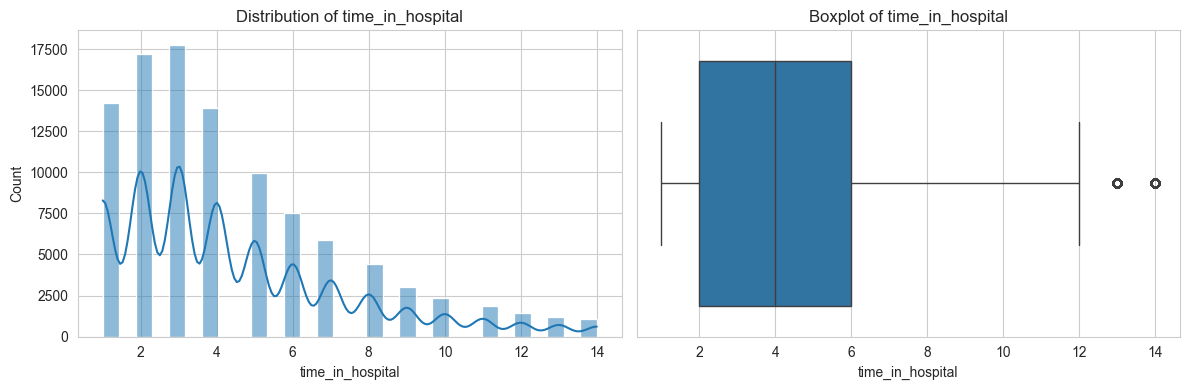

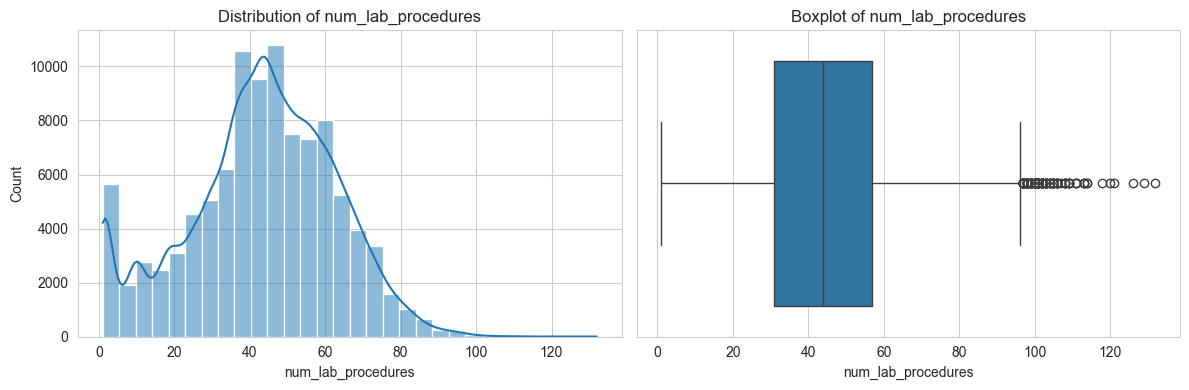

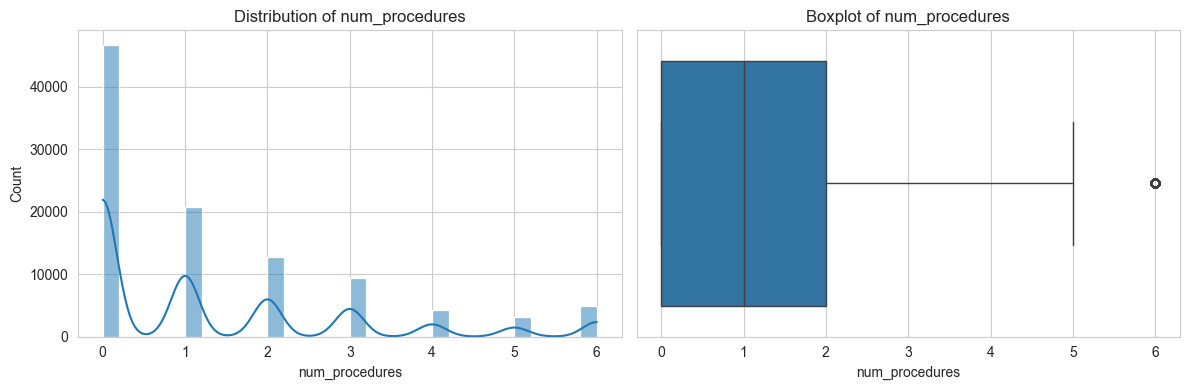

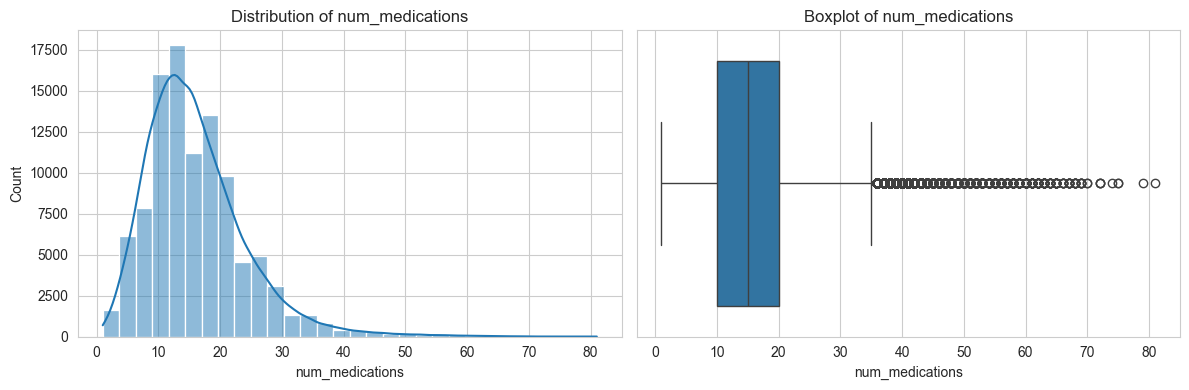

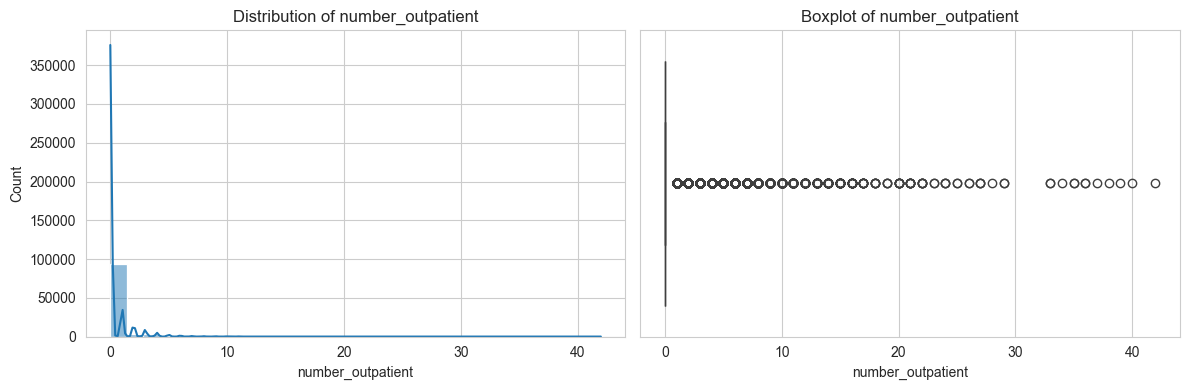

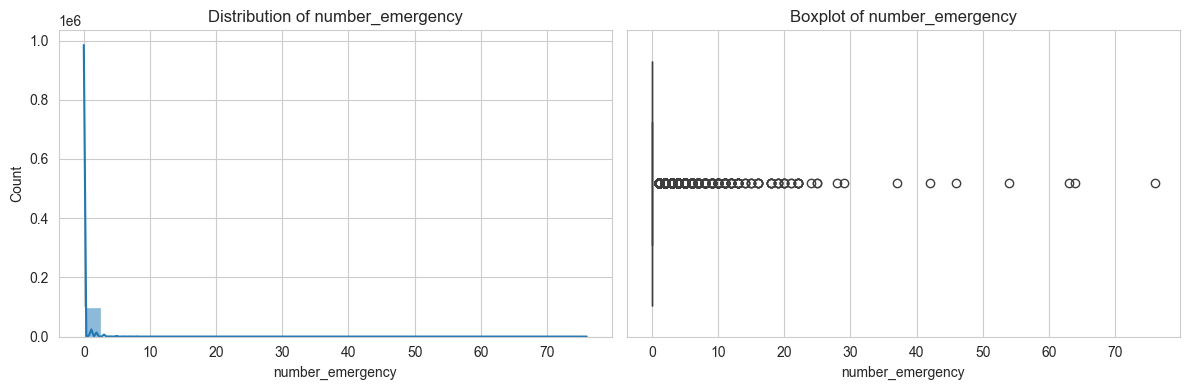

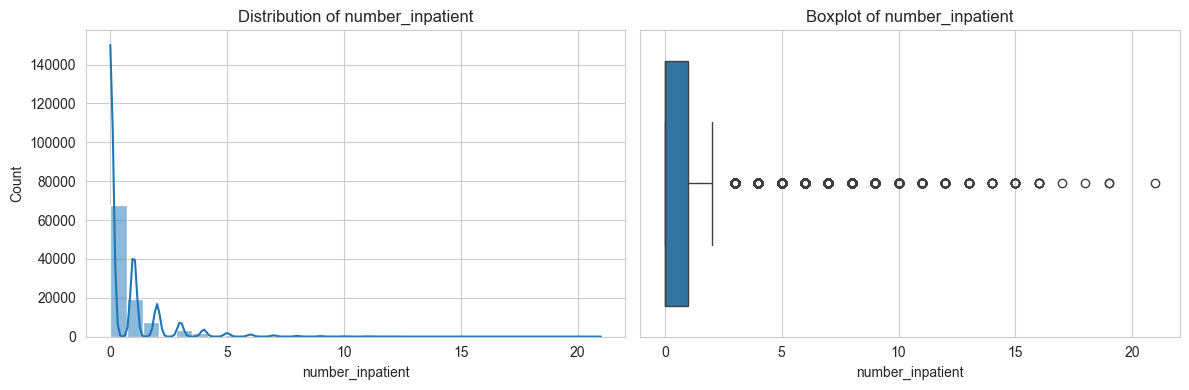

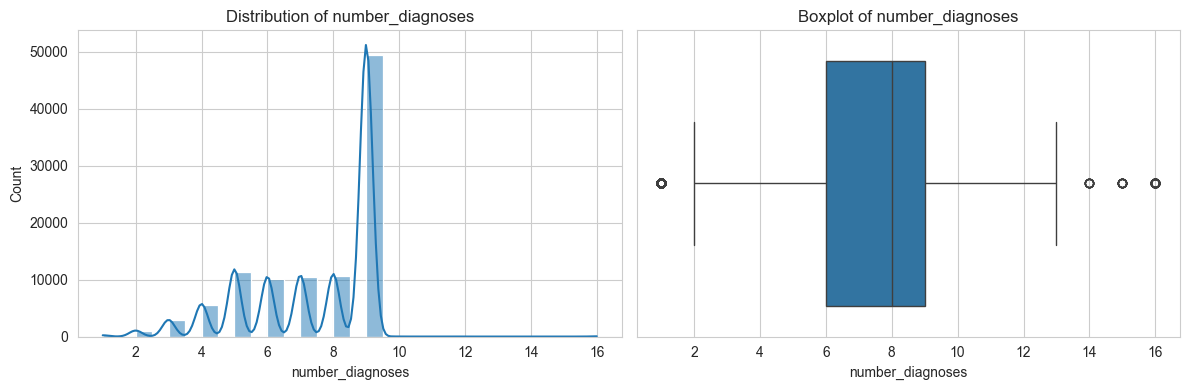

Summary statistics for numerical columns:


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [13]:
display_univariate_analysis(df_cleaned, numerical_columns)

Because of the outliers, mostnumerical columns have right-skewed distribution except for `number_diagnoses` column. But as stated earlier, the outliers are valid data and might provide more information on patients who need higher quality care more.

### Univariate analysis of the categorical columns

Given that there are 35 categorical columns, we will only analyze key columns.

In [14]:
# Split the categorical columns into groups based on their characteristics for better analysis and potential feature engineering
demographics_group = ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty']
diagnosis_group = ['diag_1', 'diag_2', 'diag_3', 'max_glue_serum', 'A1Cresult']
treatments_group = [col for col in categorical_columns if col not in demographics_group + diagnosis_group]
categorical_groups = {
    'demographics': demographics_group,
    'diagnosis': diagnosis_group,
    'treatments': treatments_group
}
print("✓ Categorical columns grouped into:")

for group_name, cols in categorical_groups.items():
    print(f"  - {group_name}: {cols}")

✓ Categorical columns grouped into:
  - demographics: ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty']
  - diagnosis: ['diag_1', 'diag_2', 'diag_3', 'max_glue_serum', 'A1Cresult']
  - treatments: ['max_glu_serum', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


✓ Univariate Analysis for Categorical Columns:


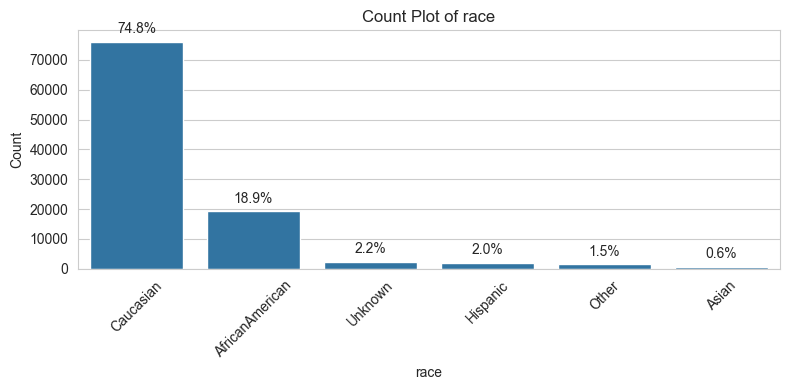

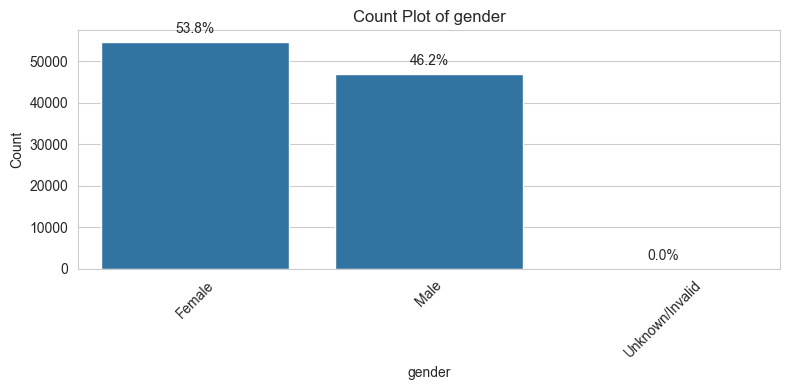

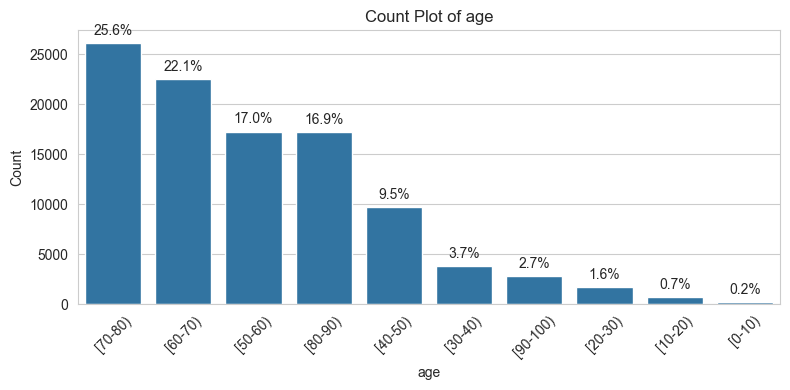

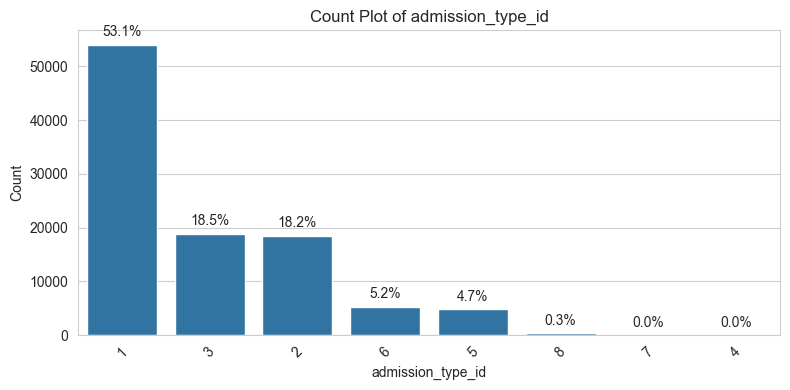

✓ Showing value counts for discharge_disposition_id (more than 10 unique values):


,count,percentage (%)
discharge_disposition_id,,
1,60234,59.2
3,13954,13.7
6,12902,12.7
18,3691,3.6
2,2128,2.1
22,1993,2.0
11,1642,1.6
5,1184,1.2
25,989,1.0


✓ Showing value counts for admission_source_id (more than 10 unique values):


,count,percentage (%)
admission_source_id,,
7,57494,56.5
1,29565,29.1
17,6781,6.7
4,3187,3.1
6,2264,2.2
2,1104,1.1
5,855,0.8
3,187,0.2
20,161,0.2


✓ Showing value counts for medical_specialty (more than 10 unique values):


,count,percentage (%)
medical_specialty,,
Unknown,49949,49.1
InternalMedicine,14635,14.4
Emergency/Trauma,7565,7.4
Family/GeneralPractice,7440,7.3
Cardiology,5352,5.3
Surgery-General,3099,3.0
Nephrology,1613,1.6
Orthopedics,1400,1.4
Orthopedics-Reconstructive,1233,1.2


In [15]:
display_univariate_analysis(df_cleaned, None, categorical_groups['demographics'])